In [2]:
import numpy as np
import pandas as pd
import random

np.random.seed(42)
random.seed(42)

records = []

for bin_id in range(1, 21):
    fill = random.uniform(5, 20)
    growth_rate = random.uniform(0.4, 1.8)  # each bin behaves differently

    for hour in range(0, 168):  # 7 days hourly
        hour_of_day = hour % 24
        day = hour // 24
        weekend = 1 if day in [5, 6] else 0

        # growth: stable + weekend effect
        base_growth = growth_rate + (0.6 if weekend else 0.2)

        # daily cycle
        daily_cycle = 0.5 * np.sin(2 * np.pi * hour_of_day / 24)

        # more realistic noise (small, centered)
        noise = np.random.normal(0, 0.35)

        fill = fill + base_growth + daily_cycle + noise
        fill = max(0, min(100, fill))

        # realistic emptying: only likely when bin is high
        if fill > 85 and random.random() < 0.25:
            fill = random.uniform(5, 15)

        records.append({
            "bin_id": f"BIN_{bin_id}",
            "hour": hour,
            "fill_level": fill,
            "hour_of_day": hour_of_day,
            "day": day,
            "weekend": weekend,
            "growth_rate": growth_rate  # keep known per-bin behaviour
        })

df = pd.DataFrame(records)

# 6-hour ahead target
df["future_fill"] = df.groupby("bin_id")["fill_level"].shift(-6)
df = df.dropna().reset_index(drop=True)

df.head()

,bin_id,hour,fill_level,hour_of_day,day,weekend,growth_rate,future_fill
0,BIN_1,0,15.400267,0,0,0,0.435015,22.459478
1,BIN_1,1,16.116299,1,0,0,0.435015,23.846058
2,BIN_1,2,17.228005,2,0,0,0.435015,24.749770
3,BIN_1,3,18.749634,3,0,0,0.435015,25.928234
4,BIN_1,4,19.735708,4,0,0,0.435015,26.651053


In [3]:
# Lag features per bin
for lag in [1, 2, 3]:
    df[f"lag_{lag}"] = df.groupby("bin_id")["fill_level"].shift(lag)

# Rolling mean of last 3 hours
df["rolling_mean_3"] = (
    df.groupby("bin_id")["fill_level"]
      .rolling(window=3)
      .mean()
      .reset_index(level=0, drop=True)
)

df = df.dropna().reset_index(drop=True)

df.head()

,bin_id,hour,fill_level,hour_of_day,day,weekend,growth_rate,future_fill,lag_1,lag_2,lag_3,rolling_mean_3
0,BIN_1,3,18.749634,3,0,0,0.435015,25.928234,17.228005,16.116299,15.400267,17.364646
1,BIN_1,4,19.735708,4,0,0,0.435015,26.651053,18.749634,17.228005,16.116299,18.571116
2,BIN_1,5,20.771738,5,0,0,0.435015,27.252472,19.735708,18.749634,17.228005,19.752360
3,BIN_1,6,22.459478,6,0,0,0.435015,27.972174,20.771738,19.735708,18.749634,20.988975
4,BIN_1,7,23.846058,7,0,0,0.435015,27.808131,22.459478,20.771738,19.735708,22.359091


In [4]:
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "fill_level", "hour_of_day", "day", "weekend", "growth_rate",
    "lag_1", "lag_2", "lag_3", "rolling_mean_3"
]
target = "future_fill"

df_sorted = df.sort_values(["bin_id", "hour"]).reset_index(drop=True)

split_index = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split_index]
test_df = df_sorted.iloc[split_index:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (2544, 9) Test size: (636, 9)


In [5]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Naive baseline (future ≈ current)
naive_preds = X_test["fill_level"].values
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_r2 = r2_score(y_test, naive_preds)

# Linear regression baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

# Random Forest (tuned a bit)
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=18,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

# Gradient Boosting
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
gbr_preds = gbr.predict(X_test)
gbr_mae = mean_absolute_error(y_test, gbr_preds)
gbr_r2 = r2_score(y_test, gbr_preds)

results_table = pd.DataFrame([
    {"Model": "Naive (future=current)", "MAE": naive_mae, "R2": naive_r2},
    {"Model": "Linear Regression", "MAE": lr_mae, "R2": lr_r2},
    {"Model": "Random Forest", "MAE": rf_mae, "R2": rf_r2},
    {"Model": "Gradient Boosting", "MAE": gbr_mae, "R2": gbr_r2},
]).sort_values("MAE")

results_table

,Model,MAE,R2
2,Random Forest,3.878237,0.791335
3,Gradient Boosting,4.530470,0.757568
0,Naive (future=current),11.144066,0.137309
1,Linear Regression,13.058805,0.311220


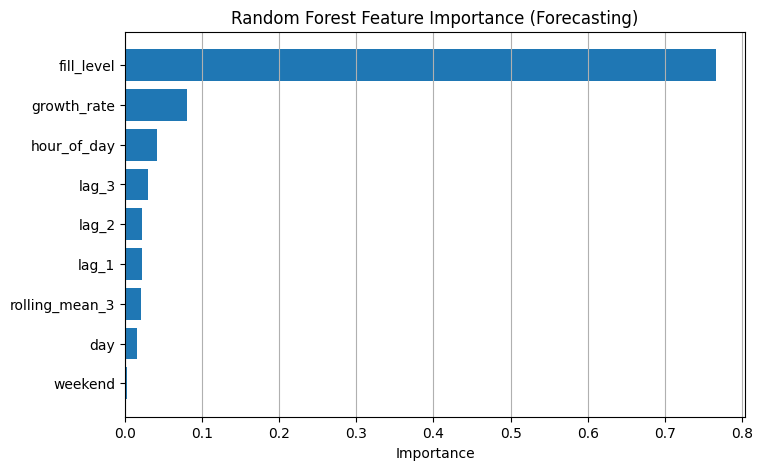

In [6]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
order = np.argsort(importances)

plt.figure(figsize=(8,5))
plt.barh(np.array(features)[order], importances[order])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (Forecasting)")
plt.grid(axis="x")
plt.show()

In [7]:
import joblib

joblib.dump(rf, "../models/fill_forecast_rf.pkl")
print("Saved: ../models/fill_forecast_rf.pkl")

def predict_future_fill(current_fill, hour, day, weekend, growth_rate,
                        lag_1, lag_2, lag_3, rolling_mean_3):
    cols = rf.feature_names_in_

    row = {
        "fill_level": current_fill,
        "hour_of_day": hour,
        "day": day,
        "weekend": weekend,
        "growth_rate": growth_rate,
        "lag_1": lag_1,
        "lag_2": lag_2,
        "lag_3": lag_3,
        "rolling_mean_3": rolling_mean_3
    }

    X_in = pd.DataFrame([[row[c] for c in cols]], columns=cols)
    return float(rf.predict(X_in)[0])

Saved: ../models/fill_forecast_rf.pkl
